In [1]:
import matplotlib.pyplot as plt
from pprint import pprint
import spikeinterface

import spikeinterface as si  # import core only
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.postprocessing as spost
import spikeinterface.qualitymetrics as sqm
import spikeinterface.comparison as sc
import spikeinterface.exporters as sexp
import spikeinterface.curation as scur
import spikeinterface.widgets as sw

#and/or
import spikeinterface.full as si

from probeinterface import Probe, get_probe
from probeinterface.plotting import plot_probe

import numpy as np
import pandas as pd
import os

C:\Users\tmerri03\AppData\Local\miniconda3\envs\SpikeSorting\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
sorting = si.load(r"C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\filtered data\filtered sorting output\sorting_TDC")
recording = si.read_openephys(r'C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\filtered data', stream_id='0')
chan_map = [
    29, 19, 18, 28, 30, 20, 17, 21,
    31, 22, 16, 23, 27, 26, 25, 24,
    7, 6, 5, 4, 8, 10, 9, 3,
    11, 2, 12, 1, 13, 0, 14, 15
]
my_probe = get_probe(manufacturer="cambridgeneurotech", probe_name="ASSY-37-H4")
my_probe.set_device_channel_indices(chan_map)
recording_probe = recording.set_probe(my_probe, group_mode='by_shank')

In [27]:
analyzer = si.create_sorting_analyzer(
    sorting=sorting,
    recording=recording_probe,
    format="binary_folder",
    folder=r"C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\filtered data\filtered sorting output\analyzer_TDC_binary",
    overwrite=True
)

estimate_sparsity (no parallelization): 100%|██████████| 9314/9314 [00:01<00:00, 7688.38it/s]
C:\Users\tmerri03\AppData\Local\miniconda3\envs\SpikeSorting\Lib\site-packages\spikeinterface\core\basesorting.py:380: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


In [28]:
if analyzer.get_extension("random_spikes") is None:
    analyzer.compute("random_spikes")
if analyzer.get_extension("waveforms") is None:
    analyzer.compute("waveforms")
if analyzer.get_extension("noise_levels") is None:
    analyzer.compute("noise_levels")
if analyzer.get_extension("templates") is None:
    analyzer.compute("templates")
if analyzer.get_extension("spike_amplitudes") is None:
    analyzer.compute("spike_amplitudes")

spike_amplitudes (no parallelization): 100%|██████████| 9314/9314 [02:05<00:00, 74.29it/s]


In [29]:
from spikeinterface_gui import run_mainwindow
run_mainwindow(analyzer, mode='desktop', curation=True)

Force compute "unit_locations" is needed


<spikeinterface_gui.backend_qt.QtMainWindow(0x26d188244c0) at 0x0000026CA31D5140>

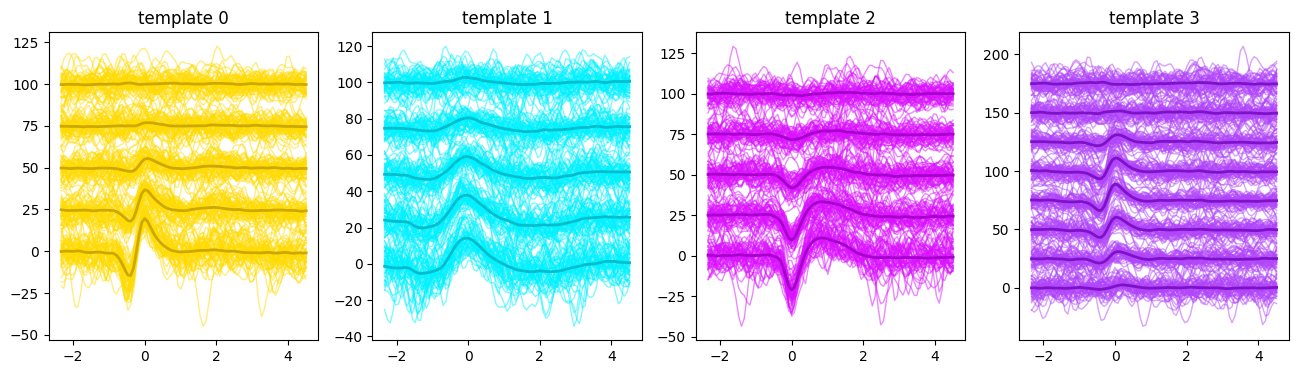

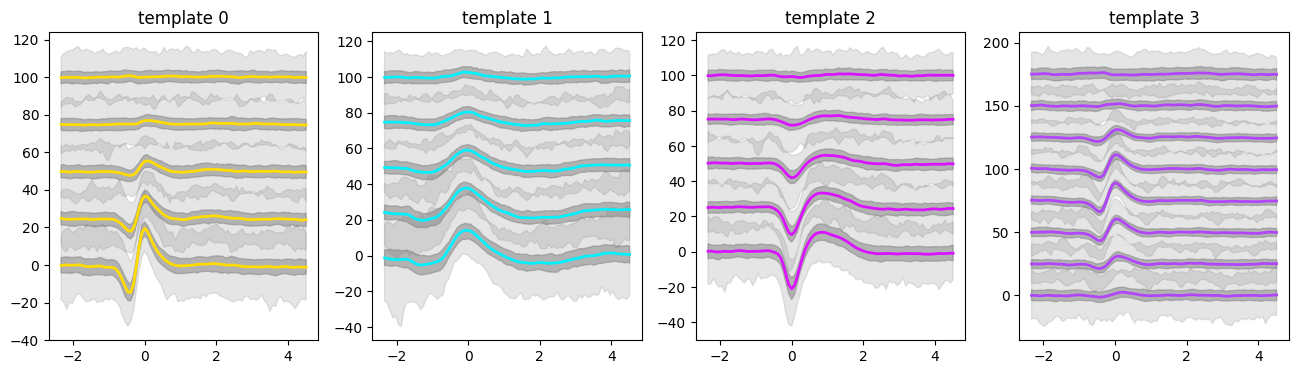

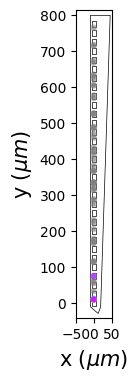

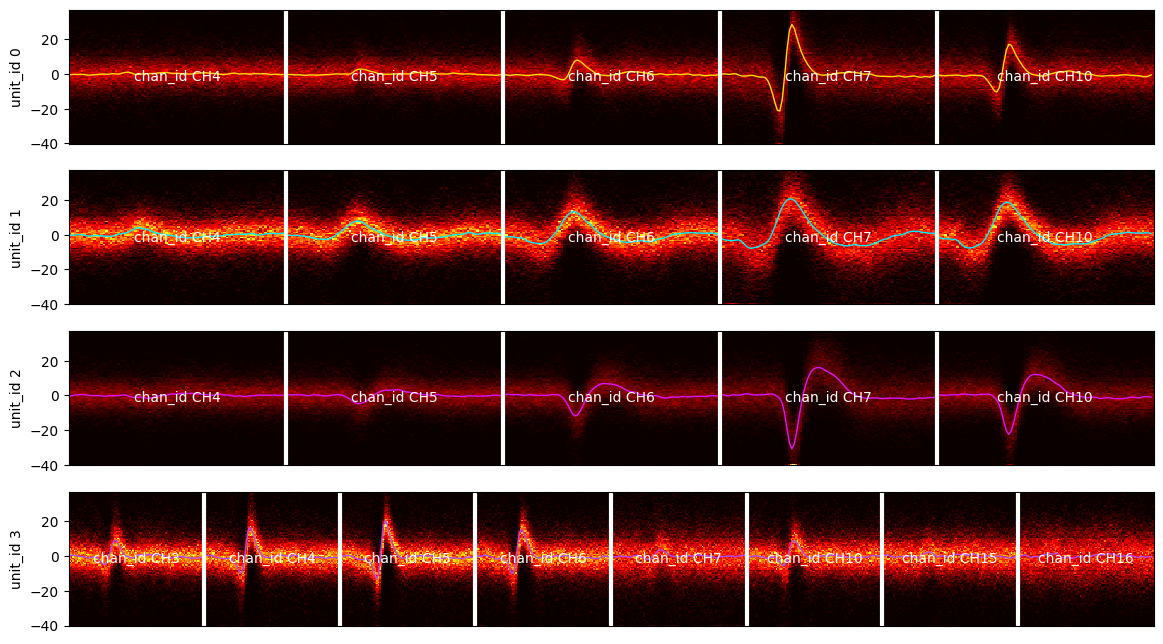

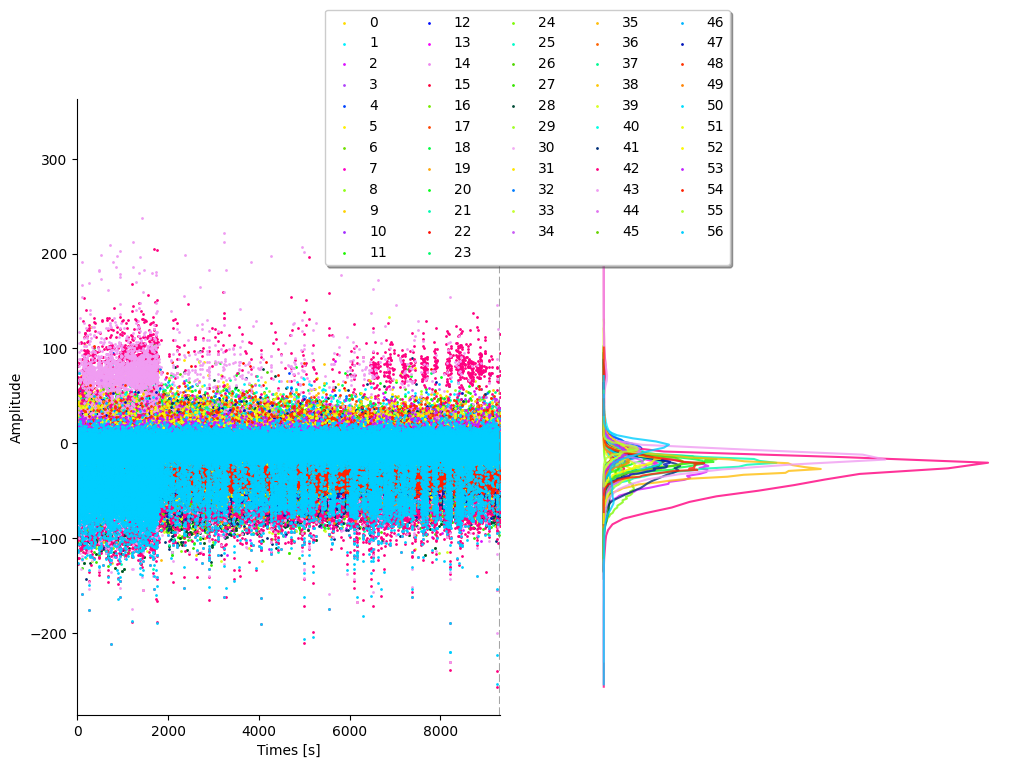

In [34]:
units = sorting.unit_ids
units = units[:4]
sw.plot_unit_waveforms(analyzer, unit_ids=units, figsize=(16,4))
sw.plot_unit_templates(analyzer, unit_ids=units, figsize=(16,4))
sw.plot_unit_locations(analyzer, unit_ids=units, figsize=(16,4))
sw.plot_unit_waveforms_density_map(analyzer, unit_ids=units, figsize=(14, 8))
sw.plot_amplitudes(analyzer, plot_histograms=True, figsize=(12, 8))



In [31]:
recording = recording_probe

In [33]:
w_ts = sw.plot_traces(recording, mode="map", time_range=(5, 5.5), show_channel_ids=True, order_channel_by_depth=True)

KeyboardInterrupt: 